##Lab 8 Kaggle workshop and pretrained models
TA: Pengyu Chang(pengyuch@andrew.cmu.edu)

Olivier Kwizera(okwizera@andrew.cmu.edu)

In this notebook, we will demonstrate how to load a pretrained ResNet-50 model using PyTorch's torchvision library. We will use this model to classify a random image downloaded from the internet.

(We don't allow using pretrained models in HWP2s, this lab is just for your future usage)

First, let's import the necessary libraries.
## Checkpoint 1:

In [1]:
import torch
import torchvision.models as models
from PIL import Image
import requests
import matplotlib.pyplot as plt

##1. Loading the Pretrained Model
PyTorch makes it incredibly easy to load state-of-the-art models that have already been trained on massive datasets (like ImageNet).
We will use the modern Weights API to load the best available weights for ResNet-50. It's crucial to put the model in evaluation mode using .eval() so that layers like Dropout and BatchNorm behave correctly for inference rather than training.
##Checkpoint 2:

In [2]:
# List all available weights for ResNet-50
for weight in models.ResNet50_Weights:
    print(weight)
# Load the best available pretrained weights for ResNet50
weights = models.ResNet50_Weights.DEFAULT
model = models.resnet50(weights=weights)

# Set the model to evaluation mode (crucial for inference!)
model.eval()

print("Model loaded successfully!")

ResNet50_Weights.IMAGENET1K_V1
ResNet50_Weights.IMAGENET1K_V2
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 172MB/s]


Model loaded successfully!


##2. Loading and Displaying an Image
Let's download a sample image of a dog from the official PyTorch repository to test our model. We will use PIL to open it and matplotlib to display it.
##Checkpoint 3:


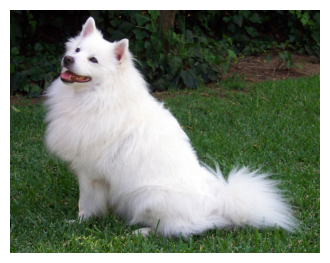

In [3]:
# Download a sample image
url = "https://raw.githubusercontent.com/pytorch/hub/master/images/dog.jpg"
image = Image.open(requests.get(url, stream=True).raw)

# Display the image
plt.figure(figsize=(4, 4))
plt.imshow(image)
plt.axis('off')
plt.show()

##3. Preprocessing the Image
Pretrained models expect input data to be formatted in the exact same way as the data they were trained on. This usually involves resizing, cropping, converting to a PyTorch tensor, and normalizing the color channels.
Fortunately, the Weights API we used earlier has a built-in .transforms() method that automatically applies the exact preprocessing steps the model expects! Models also expect a batch of images, so we use .unsqueeze(0) to add a batch dimension.

##Checkpoint 4:

In [4]:
# Initialize the inference transforms
preprocess = weights.transforms()

# Apply transforms to the image
input_tensor = preprocess(image)

# The model expects a batch of images:[batch_size, channels, height, width]
# We have a single image, so we add a dummy batch dimension at index 0
input_batch = input_tensor.unsqueeze(0)

print(f"Original image size: {image.size}")
print(f"Tensor shape after preprocessing: {input_batch.shape}")

Original image size: (1546, 1213)
Tensor shape after preprocessing: torch.Size([1, 3, 224, 224])


##4. Making a Prediction (Inference)
Now we pass the preprocessed image through the model. We use torch.no_grad() to tell PyTorch not to compute gradients, which saves memory and speeds up the process since we are only doing inference, not training.
##Checkpoint 5:

In [5]:
# Move to GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
input_batch = input_batch.to(device)

# Perform inference
with torch.no_grad():
    output = model(input_batch)

# The output has unnormalized scores (logits).
# We run them through a softmax function to get probabilities.
probabilities = torch.nn.functional.softmax(output[0], dim=0)

print("Inference complete!")

Inference complete!


##5. Interpreting the Results
The model outputs probabilities for 1,000 different ImageNet categories. Let's extract the top 3 highest probabilities and map them to their actual human-readable class names.

##Checkpoint 6:

In [6]:
# Get the top 3 most likely categories
top3_prob, top3_catid = torch.topk(probabilities, 3)

# The weights object contains the human-readable category names
categories = weights.meta["categories"]

print("Top 3 Predictions:\n" + "-"*20)
for i in range(top3_prob.size(0)):
    category_name = categories[top3_catid[i]]
    probability = top3_prob[i].item() * 100
    print(f"{i+1}. {category_name}: {probability:.2f}%")

Top 3 Predictions:
--------------------
1. Samoyed: 43.66%
2. white wolf: 2.11%
3. Pomeranian: 1.32%
